In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

#fitters

import pybobyqa
import time
import cma
import csv

In [2]:
def median_asym(df, a=2.3, sig=4):
    q = df.quantile([a/100, 0.5, 1 - a/100])
    med, lo, hi = q.loc[0.5], q.loc[a/100], q.loc[1 - a/100]
    minus, plus = med - lo, hi - med
    denom = med.replace(0, np.nan).abs()

    minus_pct = 100 * minus / denom
    plus_pct  = 100 * plus  / denom

    fmt     = lambda x: f"{x:.{sig}g}"
    fmt_unc = lambda x: f"{x:.{sig-1}g}"
    fmt_pct = lambda x: f"{x:.{sig-2}g}%"

    return pd.DataFrame({
        "median":     med.map(fmt),
        "+ unc":       plus.map(fmt_unc),
        "- unc":      minus.map(fmt_unc),
        "+ pct":  plus_pct.map(fmt_pct),
        "- pct":   minus_pct.map(fmt_pct),
    })

In [3]:
df = pd.read_csv("../Fits/replicas.csv").iloc[:, 1:]
display(median_asym(df))

,median,+ unc,- unc,+ pct,- pct
chi2dN,2.32,0.224,0.279,9.7%,12%
g2,0.2871,0.00402,0.00247,1.4%,0.86%
l,0.3577,0.0699,0.013,20%,3.6%
l2,0.0007898,0.000191,0.000178,24%,23%
N1,0.02521,0.00493,0.00168,20%,6.7%
N2,0.1352,0.0127,0.0222,9.4%,16%
N3,8.4,1.89,0.174,22%,2.1%
a1,6.077,0.0399,0.506,0.66%,8.3%
a2,5.614,0.0602,0.124,1.1%,2.2%
a3,4.422,0.0146,0.097,0.33%,2.2%


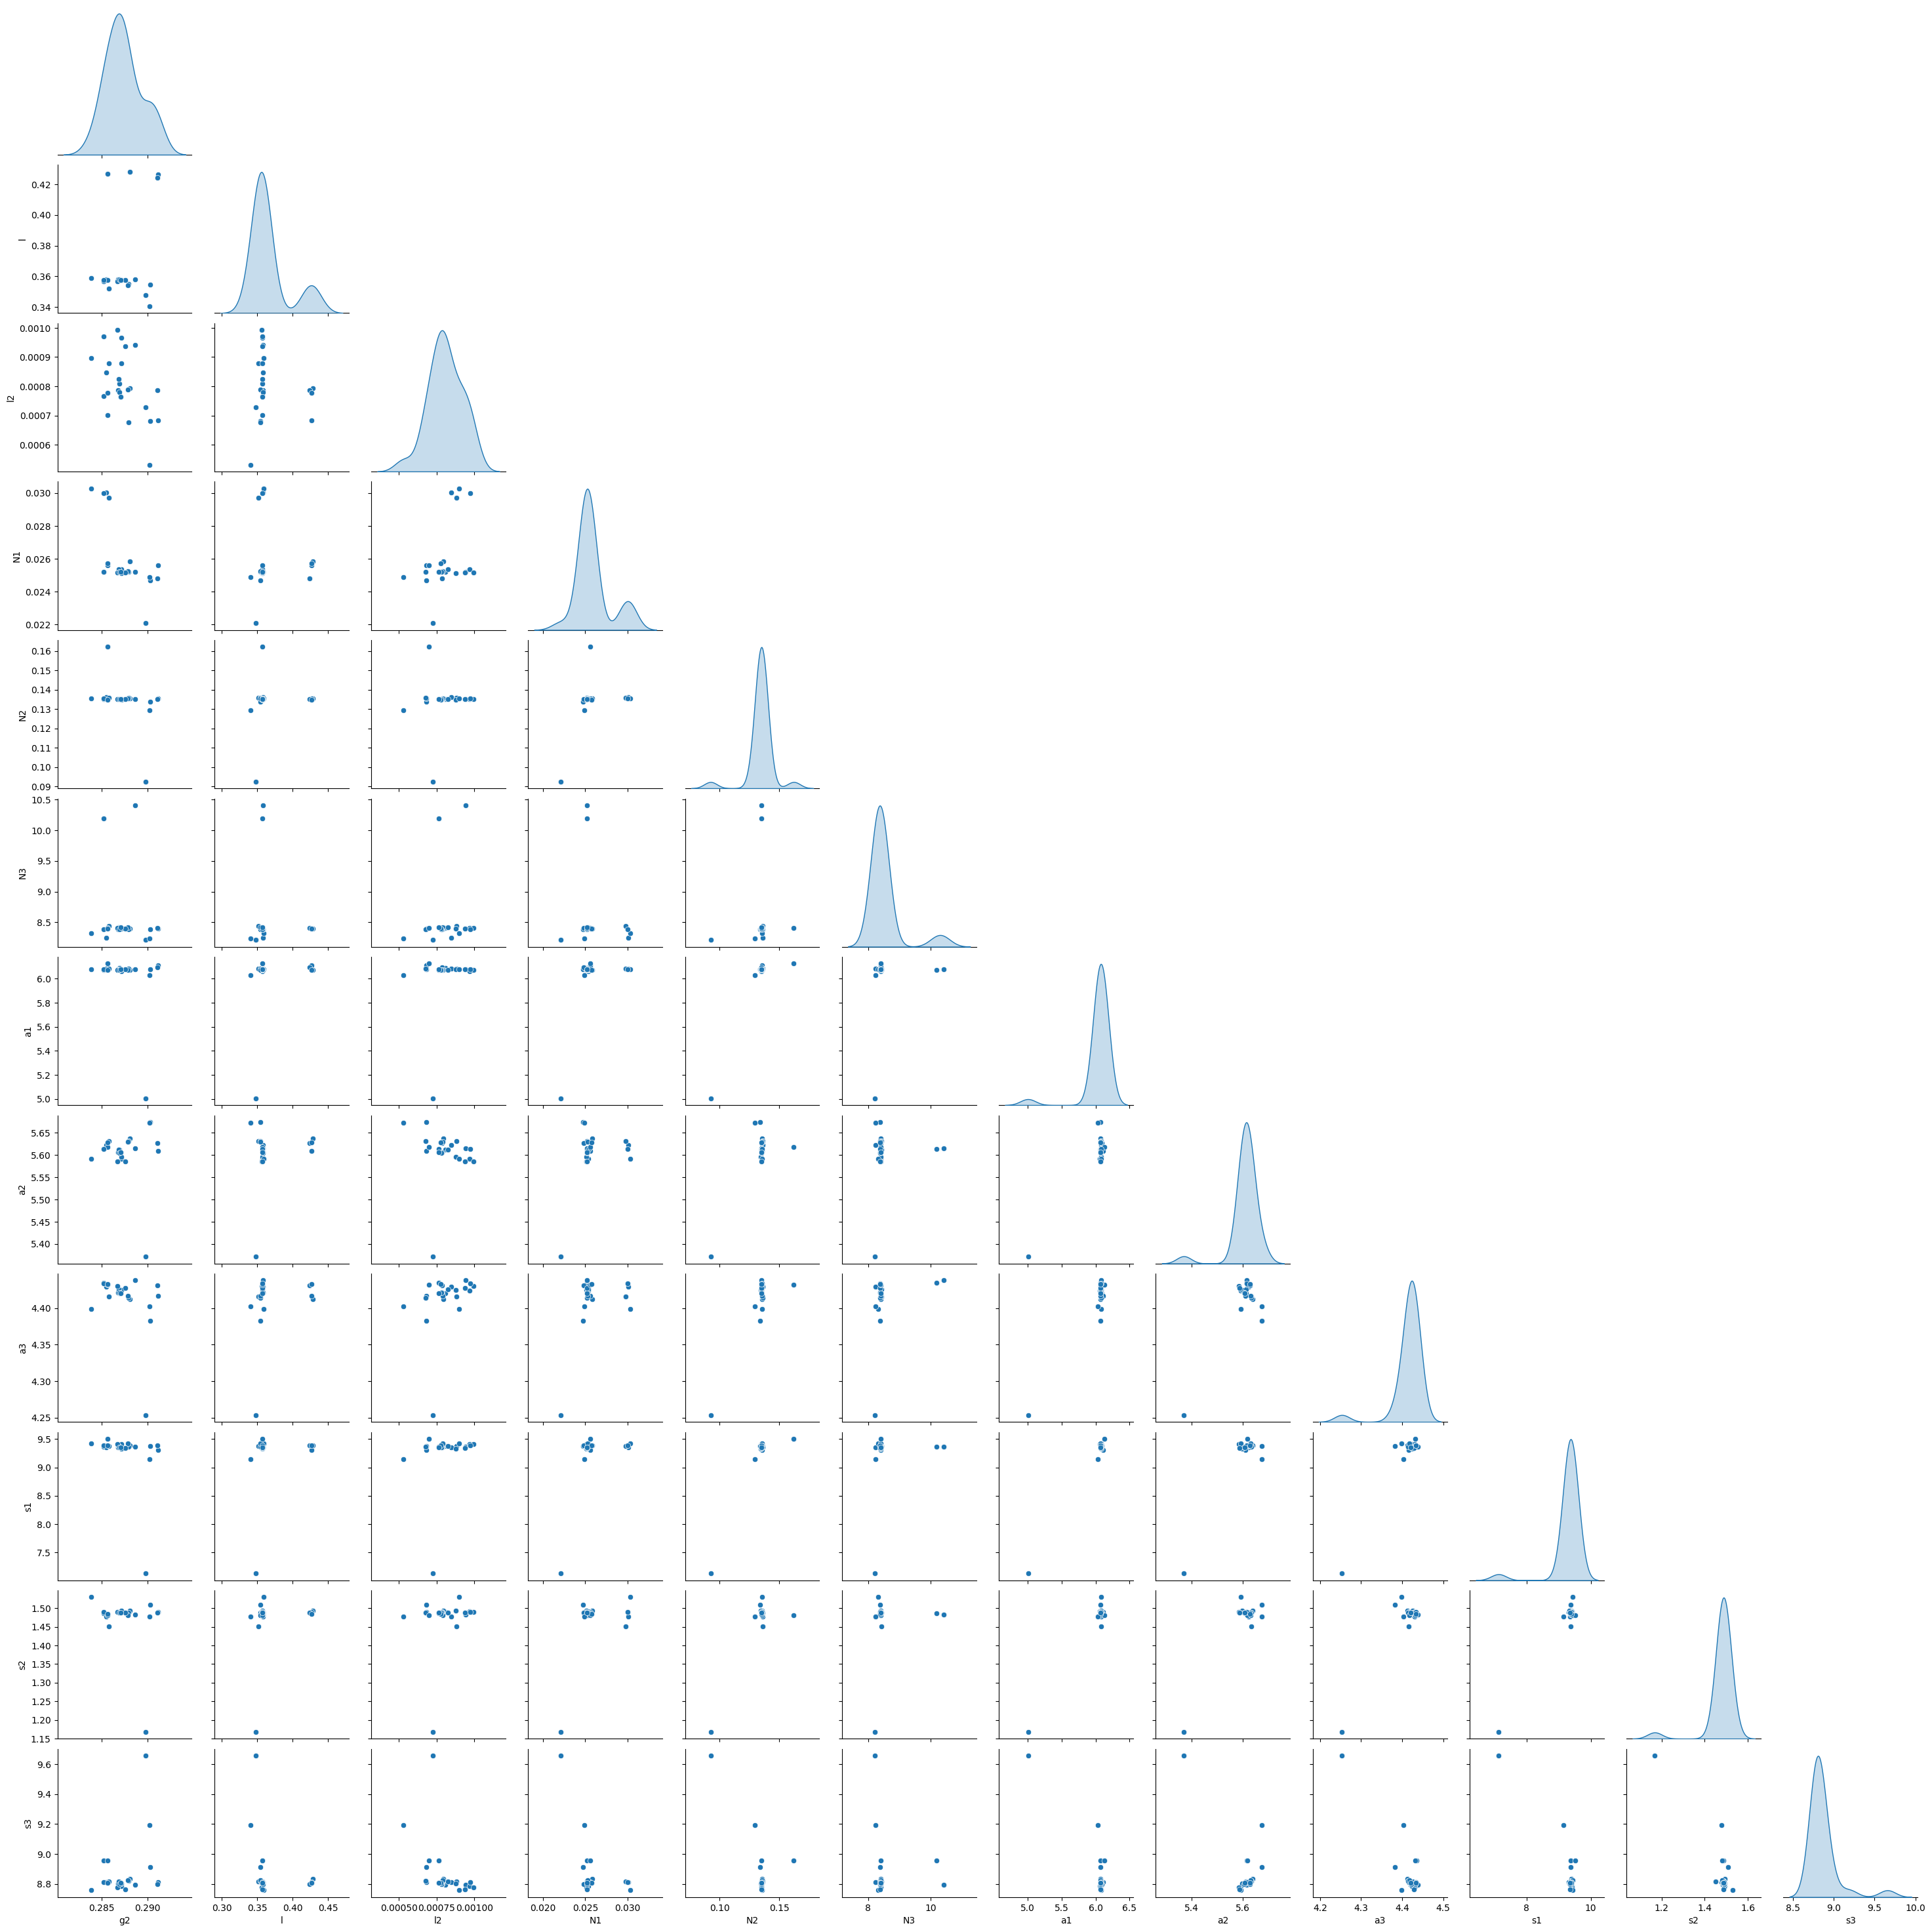

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["g2","l","l2","N1","N2","N3","a1","a2","a3","s1","s2","s3"]  
sns.pairplot(df[cols], corner=True, diag_kind="kde")  
plt.show()